# Challenge 7 — Time Series Detective

**Nombre:** Miriam Ivonne Castañeda Chavarría 
**Clase:** Series Temporales I 

## Pregunta

La dirección de la empresa afirma:

> **“Las ventas están creciendo y presentan un patrón semanal.”**

Vamos a revisar si los datos respaldan esta afirmación usando la serie de ventas de `ventas_tienda(1).csv`.


## 1. Preparar la serie

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/ivonnecastaneda/Downloads/ventas_tienda.csv")

df["fecha"] = pd.to_datetime(df["fecha"])

df = df.sort_values("fecha")
df = df.set_index("fecha")

serie = df["ventas"]

serie.head()

fecha
2025-01-01    41.21
2025-01-02    51.73
2025-01-03    51.06
2025-01-04    49.62
2025-01-05    42.36
Name: ventas, dtype: float64

## 2. Auditoría temporal

In [7]:
print("Primera fecha:", serie.index.min())
print("Última fecha:", serie.index.max())
print("Número de observaciones:", len(serie))

fechas_esperadas = pd.date_range(serie.index.min(),serie.index.max(),freq="D")
fechas_faltantes = fechas_esperadas.difference(serie.index)

print("Días faltantes:", len(fechas_faltantes))
print("Fechas faltantes:")
print(fechas_faltantes)

Primera fecha: 2025-01-01 00:00:00
Última fecha: 2025-12-31 00:00:00
Número de observaciones: 359
Días faltantes: 6
Fechas faltantes:
DatetimeIndex(['2025-02-06', '2025-03-05', '2025-04-08', '2025-06-26',
               '2025-08-16', '2025-12-04'],
              dtype='datetime64[ns]', freq=None)


Se revisan las fechas para detectar huecos en la serie. Esto es importante antes de analizar tendencias y patrones temporales.


## 3. Gráfica de las ventas

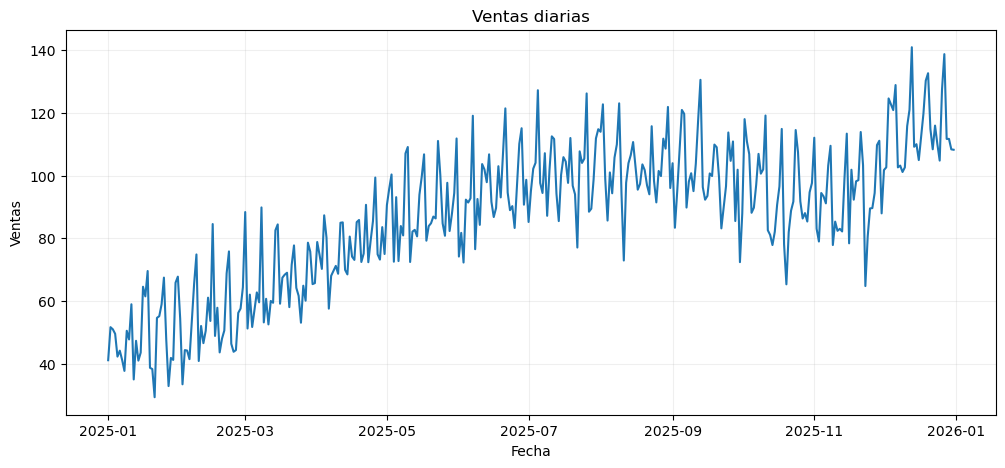

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(serie)
plt.title("Ventas diarias")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(alpha=0.2)
plt.show()

### Observación

La gráfica permite revisar visualmente si las ventas tienen una tendencia, si existen picos y si la variabilidad cambia con el tiempo.


## 4. Resampling semanal y mensual

In [11]:
serie_semanal = serie.resample("W").sum()
serie_mensual = serie.resample("ME").sum()

print("Ventas semanales:")
display(serie_semanal.head())

print("Ventas mensuales:")
display(serie_mensual)

Ventas semanales:


fecha
2025-01-05    235.98
2025-01-12    315.91
2025-01-19    366.66
2025-01-26    352.08
2025-02-02    337.95
Freq: W-SUN, Name: ventas, dtype: float64

Ventas mensuales:


fecha
2025-01-31    1520.55
2025-02-28    1455.47
2025-03-31    1980.45
2025-04-30    2246.25
2025-05-31    2796.53
2025-06-30    2751.67
2025-07-31    3140.14
2025-08-31    3075.24
2025-09-30    3026.13
2025-10-31    2924.49
2025-11-30    2803.05
2025-12-31    3444.17
Freq: ME, Name: ventas, dtype: float64

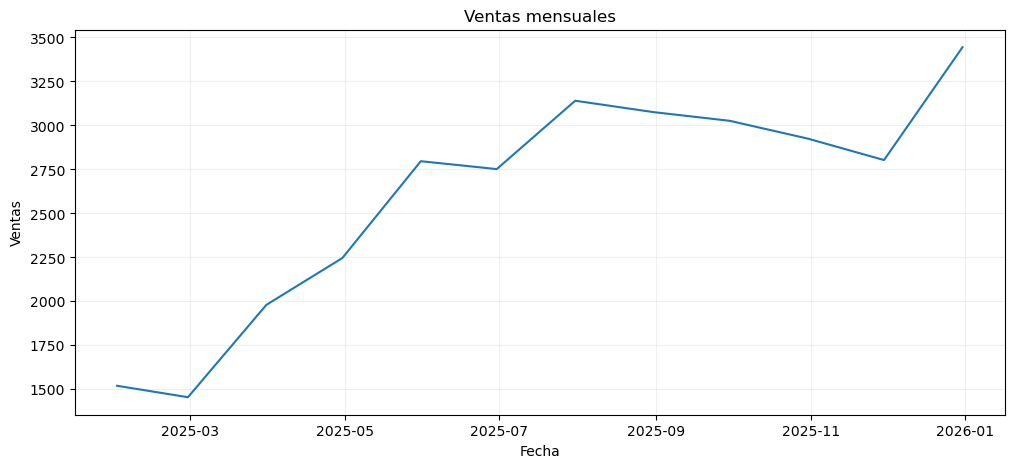

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(serie_mensual)
plt.title("Ventas mensuales")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(alpha=0.2)
plt.show()

El resampling mensual ayuda a observar mejor el comportamiento general y evita parte del ruido de las observaciones diarias.


## 5. Medias móviles MA7 y MA30

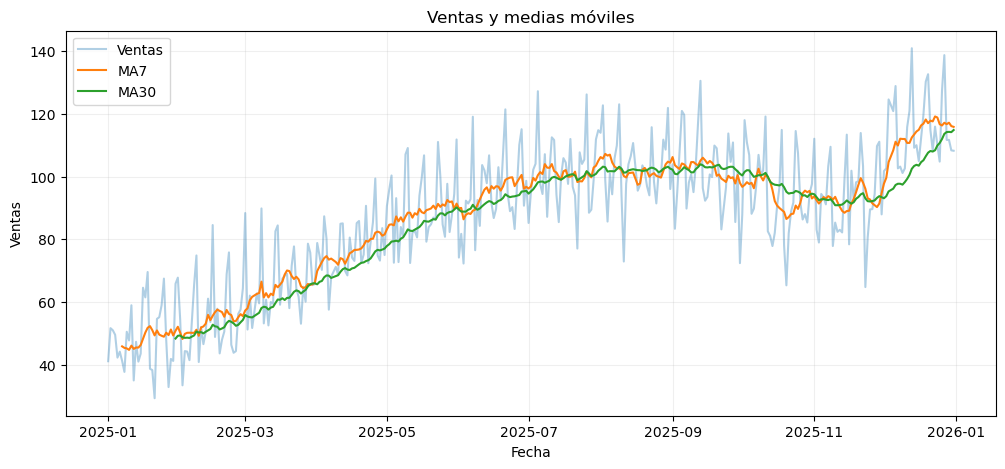

In [13]:
ma7 = serie.rolling(7).mean()
ma30 = serie.rolling(30).mean()

plt.figure(figsize=(12, 5))
plt.plot(serie, alpha=0.35, label="Ventas")
plt.plot(ma7, label="MA7")
plt.plot(ma30, label="MA30")
plt.title("Ventas y medias móviles")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Las medias móviles suavizan la serie. MA7 permite observar cambios de corto plazo y MA30 muestra mejor la tendencia general.

## 6. Revisar el patrón semanal

In [15]:
ventas_dia = serie.groupby(serie.index.dayofweek).mean()
ventas_dia.index = ["Lunes", "Martes", "Miércoles", "Jueves","Viernes", "Sábado", "Domingo"]
display(ventas_dia)

Lunes         79.754615
Martes        80.700588
Miércoles     83.858846
Jueves        87.570204
Viernes       95.137885
Sábado       103.156275
Domingo       77.719808
Name: ventas, dtype: float64

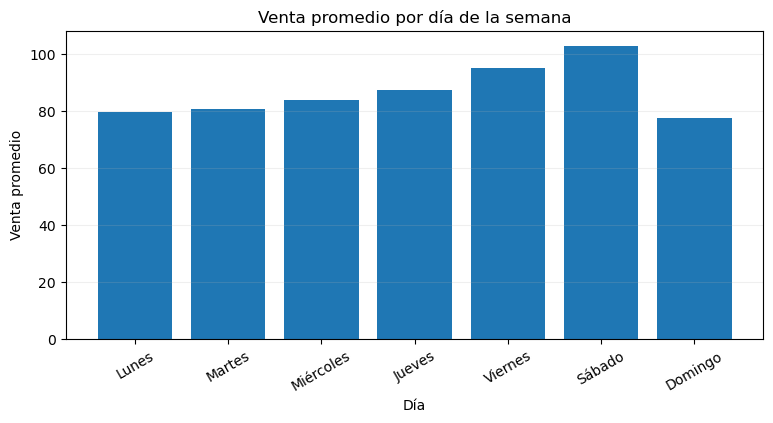

In [16]:
plt.figure(figsize=(9, 4))
plt.bar(ventas_dia.index, ventas_dia.values)
plt.title("Venta promedio por día de la semana")
plt.xlabel("Día")
plt.ylabel("Venta promedio")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.2)
plt.show()


Aquí podemos comparar si algunos días tienen ventas promedio claramente diferentes. Esto ayuda a evaluar la afirmación de que existe un patrón semanal.


## 7. Diferenciación

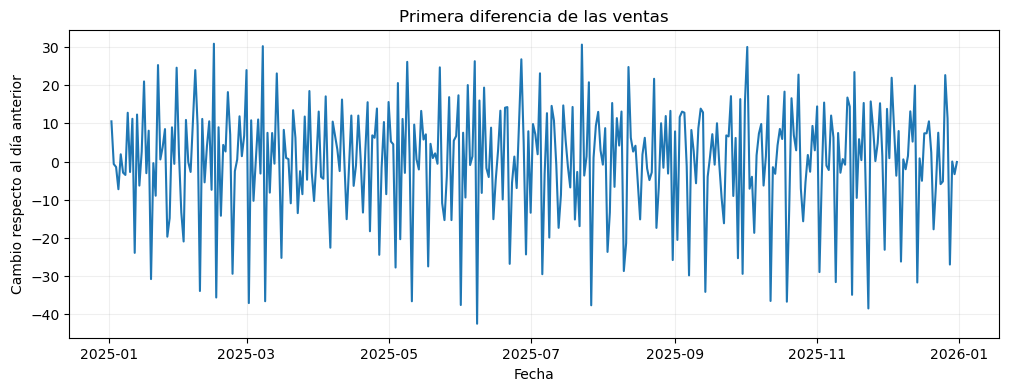

In [17]:
diferencia = serie.diff()

plt.figure(figsize=(12, 4))
plt.plot(diferencia)
plt.title("Primera diferencia de las ventas")
plt.xlabel("Fecha")
plt.ylabel("Cambio respecto al día anterior")
plt.grid(alpha=0.2)
plt.show()

## 8. Lags

In [18]:
for lag in [1, 7, 14, 30]:
    print(f"Lag {lag}: {serie.autocorr(lag):.4f}")

Lag 1: 0.7899
Lag 7: 0.8877
Lag 14: 0.8615
Lag 30: 0.5715


El lag 1 compara cada día con el día anterior. El lag 7 es especialmente importante porque permite revisar si existe una relación con el mismo día de la semana anterior.


## 9. Autocorrelación y ACF

In [19]:
print("Autocorrelación lag 1:", serie.autocorr(1))
print("Autocorrelación lag 7:", serie.autocorr(7))

Autocorrelación lag 1: 0.7898673412070162
Autocorrelación lag 7: 0.8877338872584085


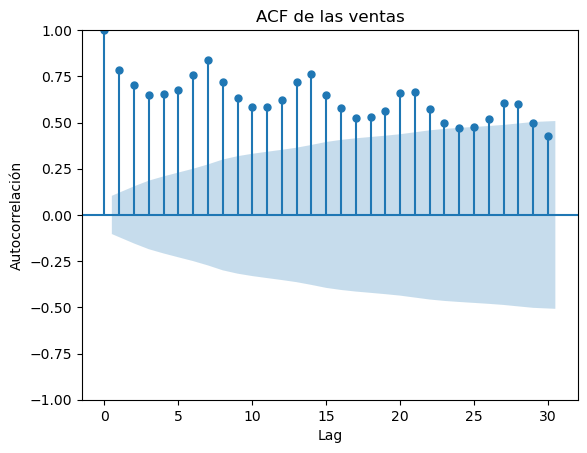

In [20]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(serie.dropna(), lags=30)
plt.title("ACF de las ventas")
plt.xlabel("Lag")
plt.ylabel("Autocorrelación")
plt.show()

## 10. Estacionariedad con ADF

In [21]:
from statsmodels.tsa.stattools import adfuller

adf_original = adfuller(serie.dropna())
adf_diferenciada = adfuller(diferencia.dropna())

print("ADF serie original")
print("Estadístico:", adf_original[0])
print("p-value:", adf_original[1])

print("\nADF serie diferenciada")
print("Estadístico:", adf_diferenciada[0])
print("p-value:", adf_diferenciada[1])

ADF serie original
Estadístico: -1.6194812418603213
p-value: 0.4730012734926608

ADF serie diferenciada
Estadístico: -9.704093101506162
p-value: 1.0531635926249655e-16


### Interpretación del ADF

La hipótesis nula de ADF es que existe raíz unitaria.

- Si `p < 0.05`, se rechaza H0.
- Si `p >= 0.05`, no se rechaza H0.

Esto permite comparar la serie original con la serie diferenciada.

# Reflexión final

1. **¿Las ventas realmente tienen tendencia?**  
   Sí se observa una tendencia ascendente en el periodo analizado. Las medias móviles también ayudan a ver este aumento.

2. **¿Existe evidencia de patrón semanal?**  
   Sí hay diferencias entre los promedios de los días de la semana. Además, el lag 7 presenta una autocorrelación alta, por lo que hay evidencia descriptiva de un patrón semanal.

3. **¿Qué lag tiene mayor relación con el presente?**  
   Entre los lags revisados, el lag 7 presenta la relación más alta.

4. **¿La serie original parece estacionaria?**  
   La prueba ADF de la serie original tiene un p-value mayor a 0.05, por lo que no se rechaza la hipótesis nula de raíz unitaria.

5. **¿La diferenciación cambia el resultado?**  
   Sí. Después de diferenciar la serie, el p-value de ADF baja por debajo de 0.05, lo que indica que la serie diferenciada presenta evidencia de estacionariedad.

6. **¿La afirmación de la dirección está respaldada?**  
   En general, los datos respaldan las dos partes de la afirmación: se observa crecimiento en las ventas y existe una relación semanal importante. Aun así, esto describe el comportamiento de los datos y no demuestra por sí solo las causas del crecimiento.
